In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [7]:
dataset = pd.read_csv("heart.csv")

In [8]:
type(dataset)


pandas.DataFrame

In [9]:
dataset.shape

(303, 14)

In [10]:
dataset.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [11]:
dataset.sample(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
150,66,1,0,160,228,0,0,138,0,2.3,2,0,1,1
296,63,0,0,124,197,0,1,136,1,0.0,1,0,2,0
290,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
105,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1
89,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1


In [12]:
dataset.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [13]:

dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [14]:
info = ["age","1: male, 0: female","chest pain type, 1: typical angina, 2: atypical angina, 3: non-anginal pain, 4: asymptomatic","resting blood pressure"," serum cholestoral in mg/dl","fasting blood sugar > 120 mg/dl","resting electrocardiographic results (values 0,1,2)"," maximum heart rate achieved","exercise induced angina","oldpeak = ST depression induced by exercise relative to rest","the slope of the peak exercise ST segment","number of major vessels (0-3) colored by flourosopy","thal: 3 = normal; 6 = fixed defect; 7 = reversable defect"]



for i in range(len(info)):
    print(dataset.columns[i]+":\t\t\t"+info[i])

age:			age
sex:			1: male, 0: female
cp:			chest pain type, 1: typical angina, 2: atypical angina, 3: non-anginal pain, 4: asymptomatic
trestbps:			resting blood pressure
chol:			 serum cholestoral in mg/dl
fbs:			fasting blood sugar > 120 mg/dl
restecg:			resting electrocardiographic results (values 0,1,2)
thalach:			 maximum heart rate achieved
exang:			exercise induced angina
oldpeak:			oldpeak = ST depression induced by exercise relative to rest
slope:			the slope of the peak exercise ST segment
ca:			number of major vessels (0-3) colored by flourosopy
thal:			thal: 3 = normal; 6 = fixed defect; 7 = reversable defect


In [15]:
dataset["target"].describe()

count    303.000000
mean       0.544554
std        0.498835
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: target, dtype: float64

In [16]:
dataset["target"].unique()

array([1, 0])

In [17]:
print(dataset.corr()["target"].abs().sort_values(ascending=False))

target      1.000000
exang       0.436757
cp          0.433798
oldpeak     0.430696
thalach     0.421741
ca          0.391724
slope       0.345877
thal        0.344029
sex         0.280937
age         0.225439
trestbps    0.144931
restecg     0.137230
chol        0.085239
fbs         0.028046
Name: target, dtype: float64


target
1    165
0    138
Name: count, dtype: int64


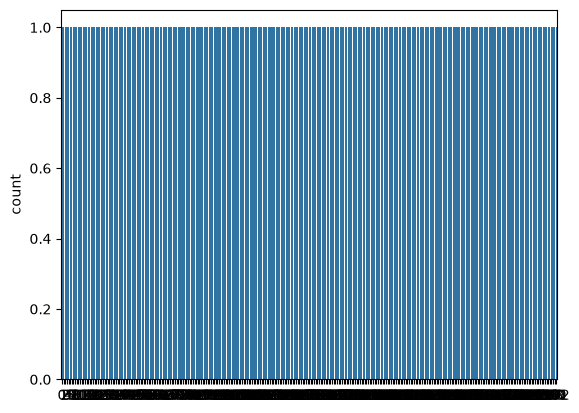

In [18]:
y = dataset["target"]

sns.countplot(y)


target_temp = dataset.target.value_counts()

print(target_temp)

In [19]:
print("Percentage of patience without heart problems: "+str(round(target_temp[0]*100/303,2)))
print("Percentage of patience with heart problems: "+str(round(target_temp[1]*100/303,2)))

Percentage of patience without heart problems: 45.54
Percentage of patience with heart problems: 54.46


In [20]:
dataset["sex"].unique()

array([1, 0])

<Axes: xlabel='sex', ylabel='target'>

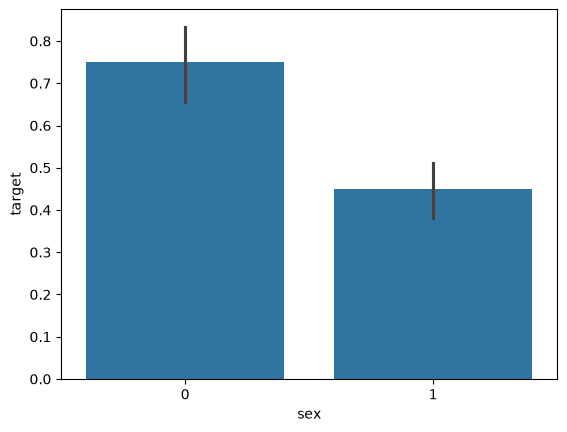

In [21]:
sns.barplot(x=dataset["sex"], y=y)



In [22]:
dataset["cp"].unique()

array([3, 2, 1, 0])

<Axes: xlabel='cp', ylabel='target'>

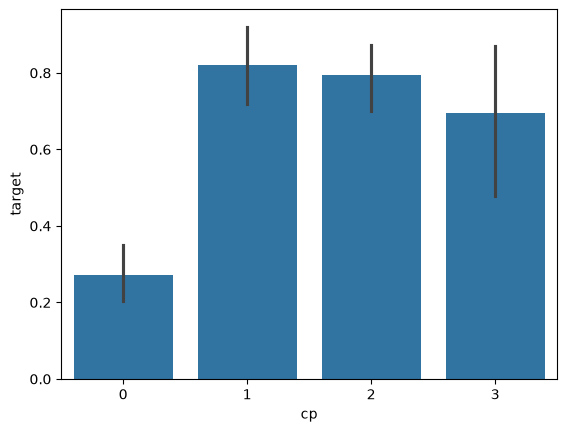

In [23]:
sns.barplot(x=dataset["cp"],y=y)

In [24]:
dataset["fbs"].describe()

count    303.000000
mean       0.148515
std        0.356198
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: fbs, dtype: float64

In [25]:
dataset["fbs"].unique()

array([1, 0])

<Axes: xlabel='fbs', ylabel='target'>

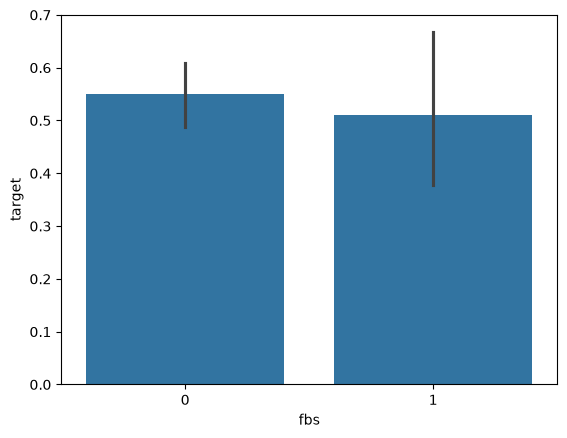

In [26]:
sns.barplot(x=dataset["fbs"],y=y)

In [27]:
dataset["restecg"].unique()

array([0, 1, 2])

<Axes: xlabel='restecg', ylabel='target'>

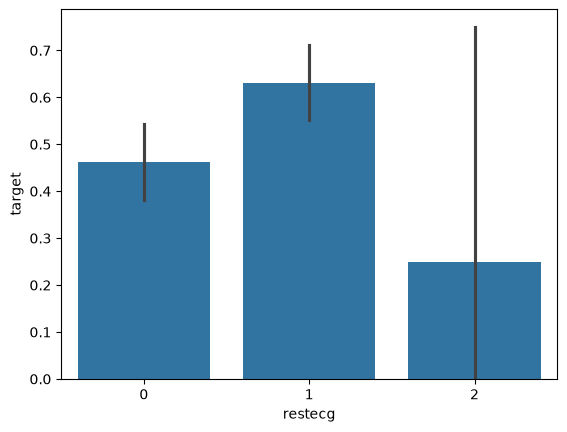

In [28]:
sns.barplot(x=dataset["restecg"],y=y)

In [29]:
dataset["exang"].unique()

array([0, 1])

<Axes: xlabel='exang', ylabel='target'>

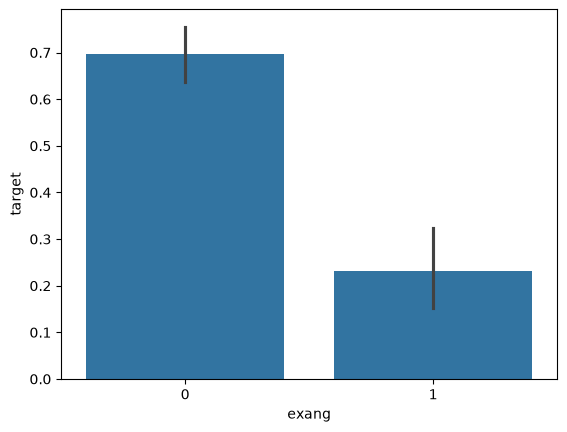

In [30]:
sns.barplot(x=dataset["exang"],y=y)

In [31]:
dataset["slope"].unique()

array([0, 2, 1])

<Axes: xlabel='slope', ylabel='target'>

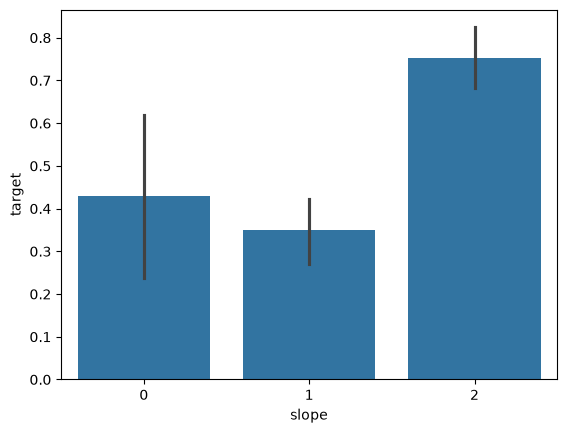

In [32]:
sns.barplot(x=dataset["slope"],y=y)

In [33]:
dataset["ca"].unique()

array([0, 2, 1, 3, 4])

<Axes: xlabel='ca', ylabel='count'>

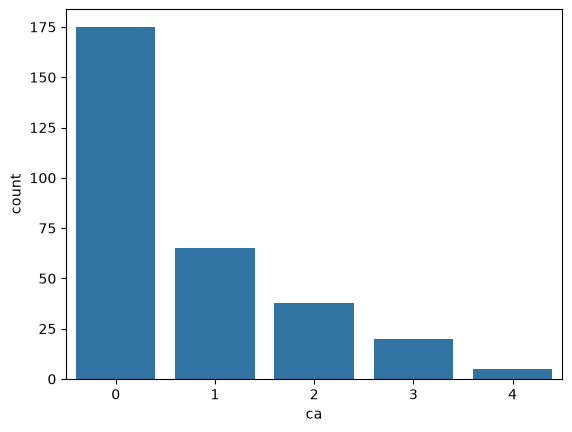

In [34]:
sns.countplot(x=dataset["ca"])

<Axes: xlabel='ca', ylabel='target'>

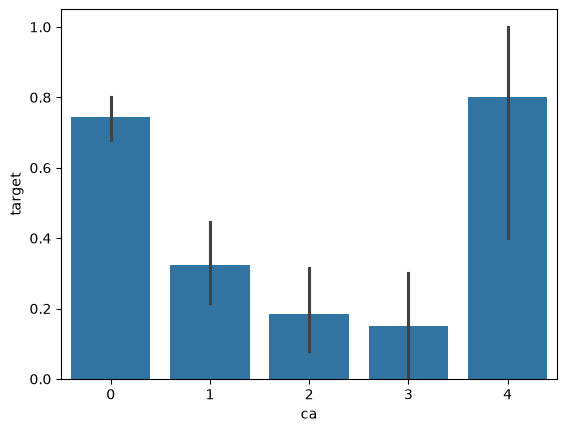

In [35]:
sns.barplot(x=dataset["ca"],y=y)

In [36]:
dataset["thal"].unique()

array([1, 2, 3, 0])

<Axes: xlabel='thal', ylabel='target'>

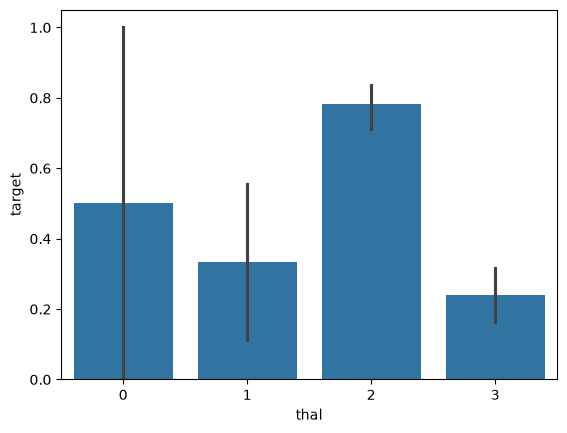

In [37]:
sns.barplot(x=dataset["thal"],y=y)

<Axes: ylabel='Density'>

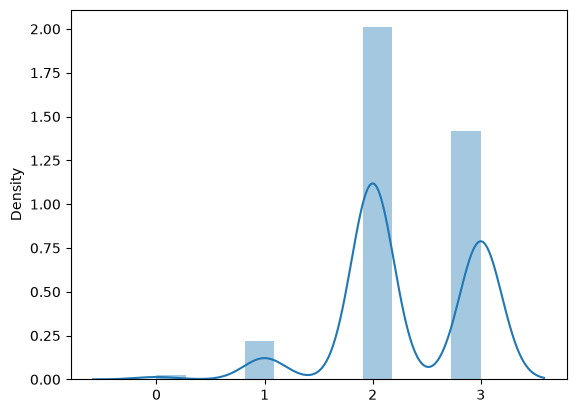

In [38]:
sns.distplot(x=dataset["thal"])

In [39]:
from sklearn.model_selection import train_test_split

predictors = dataset.drop("target",axis=1)
target = dataset["target"]

X_train,X_test,Y_train,Y_test = train_test_split(predictors,target,test_size=0.20,random_state=0)

In [40]:
X_train.shape

(242, 13)

In [41]:
X_test.shape

(61, 13)

In [42]:
Y_train.shape

(242,)

In [43]:
Y_test.shape

(61,)

In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [45]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train,Y_train)

Y_pred_lr = lr.predict(X_test)

In [46]:
Y_pred_lr.shape

(61,)

In [47]:
score_lr = round(accuracy_score(Y_pred_lr,Y_test)*100,2)
precision_lr=round(precision_score(Y_pred_lr,Y_test)*100,2)
recall_lr=round(recall_score(Y_pred_lr,Y_test)*100,2)
f1_lr=round(f1_score(Y_pred_lr,Y_test)*100,2)

print("The accuracy score achieved using Logistic Regression is: "+str(score_lr)+" %")
print("The precision score achieved using Logistic Regression is: "+str(precision_lr)+" %")
print("The recall score achieved using Logistic Regression is: "+str(recall_lr)+" %")
print("The f1 score achieved using Logistic Regression is: "+str(f1_lr)+" %")

The accuracy score achieved using Logistic Regression is: 85.25 %
The precision score achieved using Logistic Regression is: 88.24 %
The recall score achieved using Logistic Regression is: 85.71 %
The f1 score achieved using Logistic Regression is: 86.96 %


In [48]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train,Y_train)

Y_pred_nb = nb.predict(X_test)

In [49]:
Y_pred_nb.shape

(61,)

In [50]:
score_nb = round(accuracy_score(Y_pred_nb,Y_test)*100,2)
precision_nb= round(precision_score(Y_pred_nb,Y_test)*100,2)
recall_nb=round(recall_score(Y_pred_nb,Y_test)*100,2)
f1_nb=round(f1_score(Y_pred_nb,Y_test)*100,2)
print("The accuracy score achieved using Naive Bayes is: "+str(score_nb)+" %")
print("The precision score achieved using Naive Bayes is: "+str(precision_nb)+" %")
print("The recall score achieved using Naive Baye is: "+str(recall_nb)+" %")
print("The f1 score achieved using Naive Baye is: "+str(f1_nb)+" %")

The accuracy score achieved using Naive Bayes is: 85.25 %
The precision score achieved using Naive Bayes is: 91.18 %
The recall score achieved using Naive Baye is: 83.78 %
The f1 score achieved using Naive Baye is: 87.32 %


In [51]:
from sklearn import svm

sv = svm.SVC(kernel='linear')

sv.fit(X_train, Y_train)

Y_pred_svm = sv.predict(X_test)

In [52]:
Y_pred_svm.shape

(61,)

In [53]:
score_svm = round(accuracy_score(Y_pred_svm,Y_test)*100,2)
precision_svm= round(precision_score(Y_pred_svm,Y_test)*100,2)
recall_svm=round(recall_score(Y_pred_svm,Y_test)*100,2)
f1_svm=round(f1_score(Y_pred_svm,Y_test)*100,2)

print("The accuracy score achieved using Linear SVM is: "+str(score_svm)+" %")
print("The precision score achieved using Linear SVM is: "+str(precision_svm)+" %")
print("The recall score achieved using Linear SVM is: "+str(recall_svm)+" %")
print("The f1 score achieved using Linear SVM is: "+str(f1_svm)+" %")

The accuracy score achieved using Linear SVM is: 81.97 %
The precision score achieved using Linear SVM is: 88.24 %
The recall score achieved using Linear SVM is: 81.08 %
The f1 score achieved using Linear SVM is: 84.51 %


In [54]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train,Y_train)
Y_pred_knn=knn.predict(X_test)

In [55]:
Y_pred_knn.shape

(61,)

In [56]:
score_knn = round(accuracy_score(Y_pred_knn,Y_test)*100,2)
precision_knn= round(precision_score(Y_pred_knn,Y_test)*100,2)
recall_knn=round(recall_score(Y_pred_knn,Y_test)*100,2)
f1_knn=round(f1_score(Y_pred_knn,Y_test)*100,2)

print("The accuracy score achieved using KNN is: "+str(score_knn)+" %")
print("The precision score achieved using KNN is: "+str(precision_knn)+" %")
print("The recall score achieved using KNN is: "+str(recall_knn)+" %")
print("The f1 score achieved using KNN is: "+str(f1_knn)+" %")

The accuracy score achieved using KNN is: 67.21 %
The precision score achieved using KNN is: 67.65 %
The recall score achieved using KNN is: 71.88 %
The f1 score achieved using KNN is: 69.7 %


In [57]:
from sklearn.tree import DecisionTreeClassifier

max_accuracy = 0


for x in range(200):
    dt = DecisionTreeClassifier(random_state=x)
    dt.fit(X_train,Y_train)
    Y_pred_dt = dt.predict(X_test)
    current_accuracy = round(accuracy_score(Y_pred_dt,Y_test)*100,2)
    if(current_accuracy>max_accuracy):
        max_accuracy = current_accuracy
        best_x = x
        
#print(max_accuracy)
#print(best_x)


dt = DecisionTreeClassifier(random_state=best_x)
dt.fit(X_train,Y_train)
Y_pred_dt = dt.predict(X_test)

In [58]:
print(Y_pred_dt.shape)

(61,)


In [59]:
score_dt = round(accuracy_score(Y_pred_dt,Y_test)*100,2)
precision_dt= round(precision_score(Y_pred_dt,Y_test)*100,2)
recall_dt=round(recall_score(Y_pred_dt,Y_test)*100,2)
f1_dt=round(f1_score(Y_pred_dt,Y_test)*100,2)

print("The accuracy score achieved using Decision Tree is: "+str(score_dt)+" %")
print("The precision score achieved using Decision Tree is: "+str(precision_dt)+" %")
print("The recall score achieved using Decision Tree is: "+str(recall_dt)+" %")
print("The f1 score achieved using Decision Tree is: "+str(f1_dt)+" %")

The accuracy score achieved using Decision Tree is: 81.97 %
The precision score achieved using Decision Tree is: 82.35 %
The recall score achieved using Decision Tree is: 84.85 %
The f1 score achieved using Decision Tree is: 83.58 %


In [60]:
from sklearn.ensemble import RandomForestClassifier

max_accuracy = 0


for x in range(2000):
    rf = RandomForestClassifier(random_state=x)
    rf.fit(X_train,Y_train)
    Y_pred_rf = rf.predict(X_test)
    current_accuracy = round(accuracy_score(Y_pred_rf,Y_test)*100,2)
    if(current_accuracy>max_accuracy):
        max_accuracy = current_accuracy
        best_x = x
        
#print(max_accuracy)
#print(best_x)

rf = RandomForestClassifier(random_state=x)
rf.fit(X_train,Y_train)
Y_pred_rf = rf.predict(X_test)

In [61]:
Y_pred_rf.shape

(61,)

In [62]:
score_rf = round(accuracy_score(Y_pred_rf,Y_test)*100,2)
precision_rf= round(precision_score(Y_pred_rf,Y_test)*100,2)
recall_rf=round(recall_score(Y_pred_rf,Y_test)*100,2)
f1_rf=round(f1_score(Y_pred_rf,Y_test)*100,2)

print("The accuracy score achieved using Random forest Tree is: "+str(score_rf)+" %")
print("The precision score achieved using Random forest Tree is: "+str(precision_rf)+" %")
print("The recall score achieved using Random forest Tree is: "+str(recall_rf)+" %")
print("The f1 score achieved using Random forest Tree is: "+str(f1_rf)+" %")

The accuracy score achieved using Random forest Tree is: 86.89 %
The precision score achieved using Random forest Tree is: 88.24 %
The recall score achieved using Random forest Tree is: 88.24 %
The f1 score achieved using Random forest Tree is: 88.24 %


In [65]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(objective="binary:logistic", random_state=42)
xgb_model.fit(X_train, Y_train)

Y_pred_xgb = xgb_model.predict(X_test)

In [66]:
Y_pred_xgb.shape

(61,)

In [67]:
score_xgb = round(accuracy_score(Y_pred_xgb,Y_test)*100,2)
precision_xgb= round(precision_score(Y_pred_xgb,Y_test)*100,2)
recall_xgb=round(recall_score(Y_pred_xgb,Y_test)*100,2)
f1_xgb=round(f1_score(Y_pred_xgb,Y_test)*100,2)


print("The accuracy score achieved using XGBoost is: "+str(score_xgb)+" %")
print("The precision score achieved using XGBoost is: "+str(precision_xgb)+" %")
print("The recall score achieved using XGBoost is: "+str(recall_xgb)+" %")
print("The f1 score achieved using XGBoost is: "+str(f1_xgb)+" %")

The accuracy score achieved using XGBoost is: 83.61 %
The precision score achieved using XGBoost is: 85.29 %
The recall score achieved using XGBoost is: 85.29 %
The f1 score achieved using XGBoost is: 85.29 %


In [68]:
scores = [score_lr,score_nb,score_svm,score_knn,score_dt,score_rf,score_xgb]
precision = [precision_lr,precision_nb,precision_svm,precision_knn,precision_dt,precision_rf,precision_xgb]
recall = [recall_lr,recall_nb,recall_svm,recall_knn,recall_dt,recall_rf,recall_xgb]
f1 = [f1_lr,f1_nb,f1_svm,f1_knn,f1_dt,f1_rf,f1_xgb]
algorithms = ["Logistic Regression","Naive Bayes","Support Vector Machine","K-Nearest Neighbors","Decision Tree","Random Forest","XGBoost"]    

for i in range(len(algorithms)):
    print("The accuracy score achieved using "+algorithms[i]+" is: "+str(scores[i])+" %")
    print("The precision score achieved using "+algorithms[i]+" is: "+str(precision[i])+" %")
    print("The recall score achieved using "+algorithms[i]+" is: "+str(recall[i])+" %")
    print("The f1 score achieved using "+algorithms[i]+" is: "+str(f1[i])+" %")

The accuracy score achieved using Logistic Regression is: 85.25 %
The precision score achieved using Logistic Regression is: 88.24 %
The recall score achieved using Logistic Regression is: 85.71 %
The f1 score achieved using Logistic Regression is: 86.96 %
The accuracy score achieved using Naive Bayes is: 85.25 %
The precision score achieved using Naive Bayes is: 91.18 %
The recall score achieved using Naive Bayes is: 83.78 %
The f1 score achieved using Naive Bayes is: 87.32 %
The accuracy score achieved using Support Vector Machine is: 81.97 %
The precision score achieved using Support Vector Machine is: 88.24 %
The recall score achieved using Support Vector Machine is: 81.08 %
The f1 score achieved using Support Vector Machine is: 84.51 %
The accuracy score achieved using K-Nearest Neighbors is: 67.21 %
The precision score achieved using K-Nearest Neighbors is: 67.65 %
The recall score achieved using K-Nearest Neighbors is: 71.88 %
The f1 score achieved using K-Nearest Neighbors is: 

<Axes: xlabel='Algorithms', ylabel='Accuracy score'>

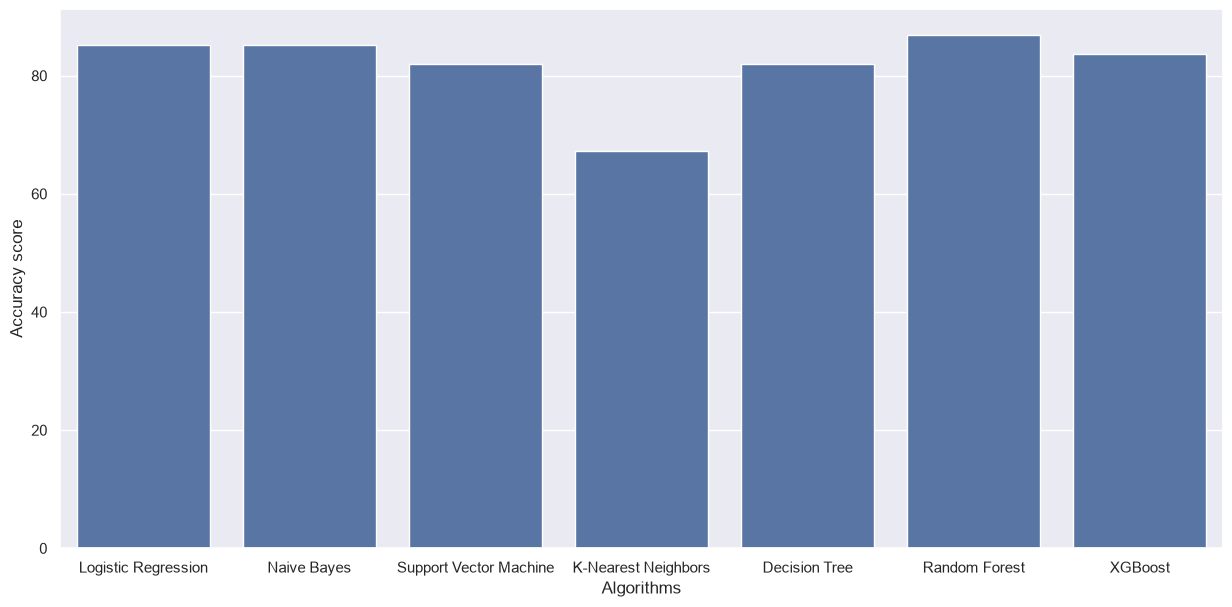

In [69]:
sns.set(rc={'figure.figsize':(15,7)})
plt.xlabel("Algorithms")
plt.ylabel("Accuracy score")

sns.barplot(x=algorithms,y=scores)